In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import gridspec
import MATS

import seaborn as sns
sns.set_style("whitegrid")
sns.set_style("ticks")
sns.set_context("poster")


HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [2]:
from MATS.linelistdata import linelistdata

PARAM_LINELIST = linelistdata['O2_ABand_Drouin_2017_linelist']
PARAM_LINELIST['nuOptRe_air'] = PARAM_LINELIST['nuVC_air']
PARAM_LINELIST['n_nuOptRe_air'] = 0
PARAM_LINELIST['nuOptIm_air'] = 0
PARAM_LINELIST['n_nuOptIm_air'] = 0
PARAM_LINELIST.sort_values(by = 'nu', inplace = True)

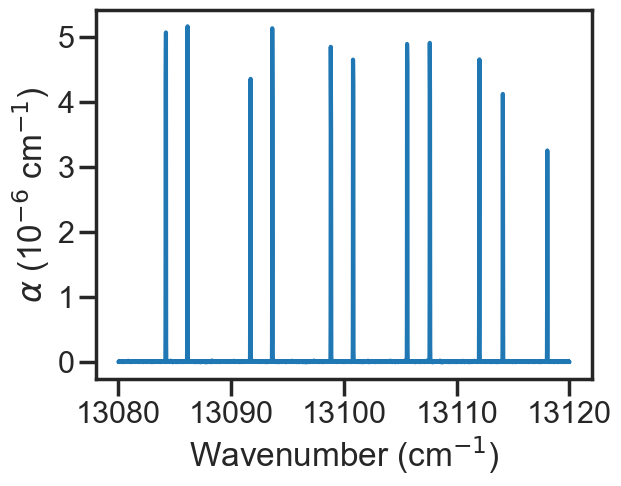

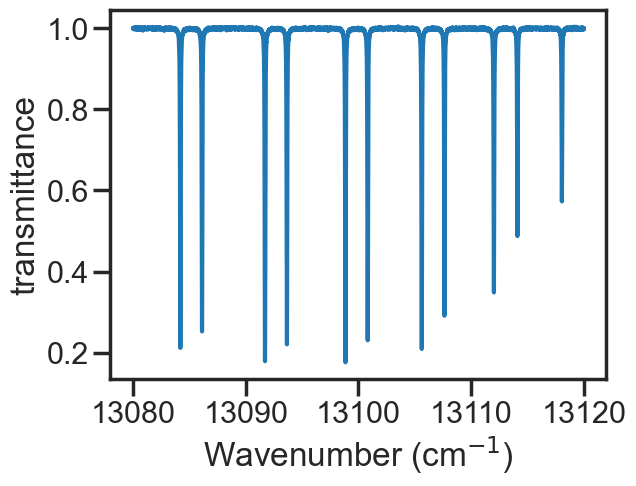

In [3]:
#Example of Simulating

#Experiment Spectrum 

wave_range = 1.5 #range outside of experimental x-range to simulate
IntensityThreshold = 1e-30 #intensities must be above this value to be simulated
Fit_Intensity = 1e-24 #intensities must be above this value for the line to be fit
order_baseline_fit = 1
wave_min = 13080 #cm-1
wave_max = 13120 #cm-1
wave_space = 0.005 #cm-1
baseline_terms = [0] #polynomial baseline coefficients where the index is equal to the coefficient order
lineprofile = 'mHTP'



#CRDS
def simulate_CRDS(pressure, O2_molefraction):

    wavenumbers = np.arange(wave_min, wave_max + wave_space, wave_space)
    
    spec =  MATS.simulate_spectrum(PARAM_LINELIST, wavenumbers = wavenumbers, lineprofile = lineprofile, sim_window = wave_range, 
                            SNR = 2500, filename = 'temp',
                            molefraction = {7 :O2_molefraction}, 
                            temperature = 296, temperature_err = {'bias': 0.01, 'function': None, 'params': {}}, pressure = pressure,  pressure_err = {'per_bias': 0.01, 'function': None, 'params': {}})

    within_dynamic_range_wavenumbers = wavenumbers[spec.y_data*75 < 400]
    CRDS_spec =  MATS.simulate_spectrum(PARAM_LINELIST, wavenumbers = within_dynamic_range_wavenumbers, lineprofile = lineprofile, sim_window = wave_range, 
                            SNR = 2500, filename = 'temp',
                            molefraction = {7 :O2_molefraction}, 
                            temperature = 296, temperature_err = {'bias': 0.01, 'function': None, 'params': {}}, pressure = pressure,  pressure_err = {'per_bias': 0.01, 'function': None, 'params': {}})


    return CRDS_spec

def simulate_FTS(pressure, temperature, O2_molefraction, pathlength):
    wavenumbers = np.arange(wave_min, wave_max + wave_space, wave_space)
    
    FTS_spec =  MATS.simulate_spectrum(PARAM_LINELIST, wavenumbers = wavenumbers, lineprofile = lineprofile, sim_window = wave_range, 
                                       dataspace = 'transmittance', pathlength = pathlength,
                            SNR = 800, filename = 'temp',
                            molefraction = {7 :O2_molefraction}, 
                            temperature = temperature, temperature_err = {'bias': 0.2, 'function': None, 'params': {}}, pressure = pressure,  pressure_err = {'per_bias': 0.1, 'function': None, 'params': {}})

    return FTS_spec
    
    
    
CRDS_spec_1 = simulate_CRDS(0.0013, 1)
CRDS_spec_2 = simulate_CRDS(0.0013, 0.20720)
CRDS_spec_3 = simulate_CRDS(0.526, 0.20720)
CRDS_spec_4 = simulate_CRDS(1.297, 0.20720)

FTS_spec_1 = simulate_FTS(0.327, 297.2, 0.20720, 82.73*100)
FTS_spec_2 = simulate_FTS(0.264, 296.9, 0.20720,99.25*100)
FTS_spec_3 = simulate_FTS(0.530, 297.2, 0.20720,99.25*100)
FTS_spec_4 = simulate_FTS(0.396, 294.9, 0.3250, 99.25*100)
FTS_spec_5 = simulate_FTS(0.191, 295.8, 0.1057,99.25*100)
FTS_spec_6 = simulate_FTS(0.263, 297.1, 1,52*100)
FTS_spec_7 = simulate_FTS(0.662, 297.5, 1,52*100)



CRDS_spec_1.plot_wave_y()
FTS_spec_1.plot_wave_y()

In [4]:
SPECTRA = MATS.Dataset([CRDS_spec_1, CRDS_spec_2, CRDS_spec_3, CRDS_spec_4, 
                       FTS_spec_1, FTS_spec_2, FTS_spec_3, FTS_spec_4, FTS_spec_5, FTS_spec_6, FTS_spec_7], 'Fit Testing', PARAM_LINELIST)

#Generate Baseline Parameter list based on number of etalons in spectra definitions and baseline order
BASE_LINELIST = SPECTRA.generate_baseline_paramlist()

#Generate Fit Params
FITPARAMS = MATS.Generate_FitParam_File(SPECTRA, PARAM_LINELIST, BASE_LINELIST, lineprofile = 'SDVP', linemixing = True, 
                                  fit_intensity = Fit_Intensity, threshold_intensity = IntensityThreshold, sim_window = wave_range,
                                  nu_constrain = True, sw_constrain = True, gamma0_constrain = True, delta0_constrain = True, 
                                   aw_constrain = True, as_constrain = True, 
                                   nuVC_constrain = True, eta_constrain =True, linemixing_constrain = True)


FITPARAMS.generate_fit_param_linelist_from_linelist(vary_nu = {7:{1:True}}, vary_sw = {77:{1:True}},
                                                    vary_gamma0 = {7:{1:True}}, 
                                                    vary_delta0 = {7:{1:True}},  
                                                    vary_aw = {7:{1:True}}, 
                                                    vary_as = {},   vary_linemixing = {5:{1:True}})

FITPARAMS.generate_fit_baseline_linelist(vary_baseline = False, vary_molefraction = {7:False, 1:False}, vary_xshift = False, vary_pressure = False, 
                                        vary_pathlength = False)







,Segment Number,Pressure,Pressure_err,Pressure_vary,Temperature,Temperature_err,Temperature_vary,x_shift,x_shift_err,x_shift_vary,molefraction_O2,molefraction_O2_err,molefraction_O2_vary,baseline_a,baseline_a_err,baseline_a_vary,pathlength,pathlength_err,pathlength_vary
Spectrum Number,,,,,,,,,,,,,,,,,,,
1,1,0.001300,0.0,False,296.01,0.0,False,0.0,0.0,False,1.0000,0.0,False,0.0,0.0,False,0.0,0.0,False
2,1,0.001300,0.0,False,296.01,0.0,False,0.0,0.0,False,0.2072,0.0,False,0.0,0.0,False,0.0,0.0,False
3,1,0.526053,0.0,False,296.01,0.0,False,0.0,0.0,False,0.2072,0.0,False,0.0,0.0,False,0.0,0.0,False
4,1,1.297130,0.0,False,296.01,0.0,False,0.0,0.0,False,0.2072,0.0,False,0.0,0.0,False,0.0,0.0,False
5,1,0.327327,0.0,False,297.40,0.0,False,0.0,0.0,False,0.2072,0.0,False,0.0,0.0,False,8273.0,0.0,False
6,1,0.264264,0.0,False,297.10,0.0,False,0.0,0.0,False,0.2072,0.0,False,0.0,0.0,False,9925.0,0.0,False
7,1,0.530530,0.0,False,297.40,0.0,False,0.0,0.0,False,0.2072,0.0,False,0.0,0.0,False,9925.0,0.0,False
8,1,0.396396,0.0,False,295.10,0.0,False,0.0,0.0,False,0.3250,0.0,False,0.0,0.0,False,9925.0,0.0,False
9,1,0.191191,0.0,False,296.00,0.0,False,0.0,0.0,False,0.1057,0.0,False,0.0,0.0,False,9925.0,0.0,False


Name                     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Pressure_10_1           0.2633     -inf      inf        0    False     None     None
Pressure_11_1           0.6627     -inf      inf        0    False     None     None
Pressure_1_1            0.0013     -inf      inf        0    False     None     None
Pressure_2_1            0.0013     -inf      inf        0    False     None     None
Pressure_3_1            0.5261     -inf      inf        0    False     None     None
Pressure_4_1             1.297     -inf      inf        0    False     None     None
Pressure_5_1            0.3273     -inf      inf        0    False     None     None
Pressure_6_1            0.2643     -inf      inf        0    False     None     None
Pressure_7_1            0.5305     -inf      inf        0    False     None     None
Pressure_8_1            0.3964     -inf      inf        0    False     None     None
Pressure_9_1            0.1912     -inf      inf        0    Fa

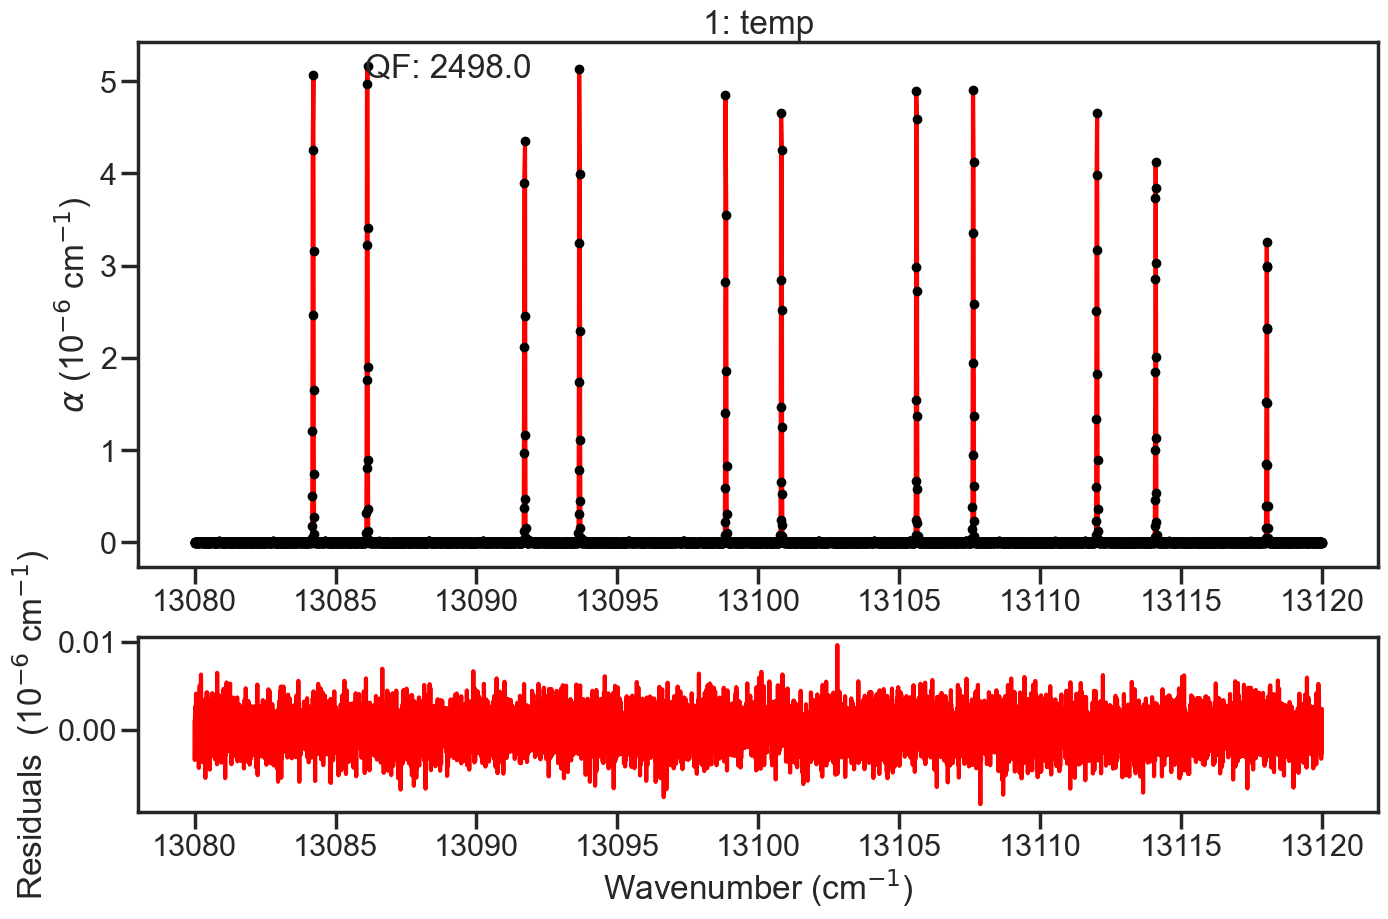

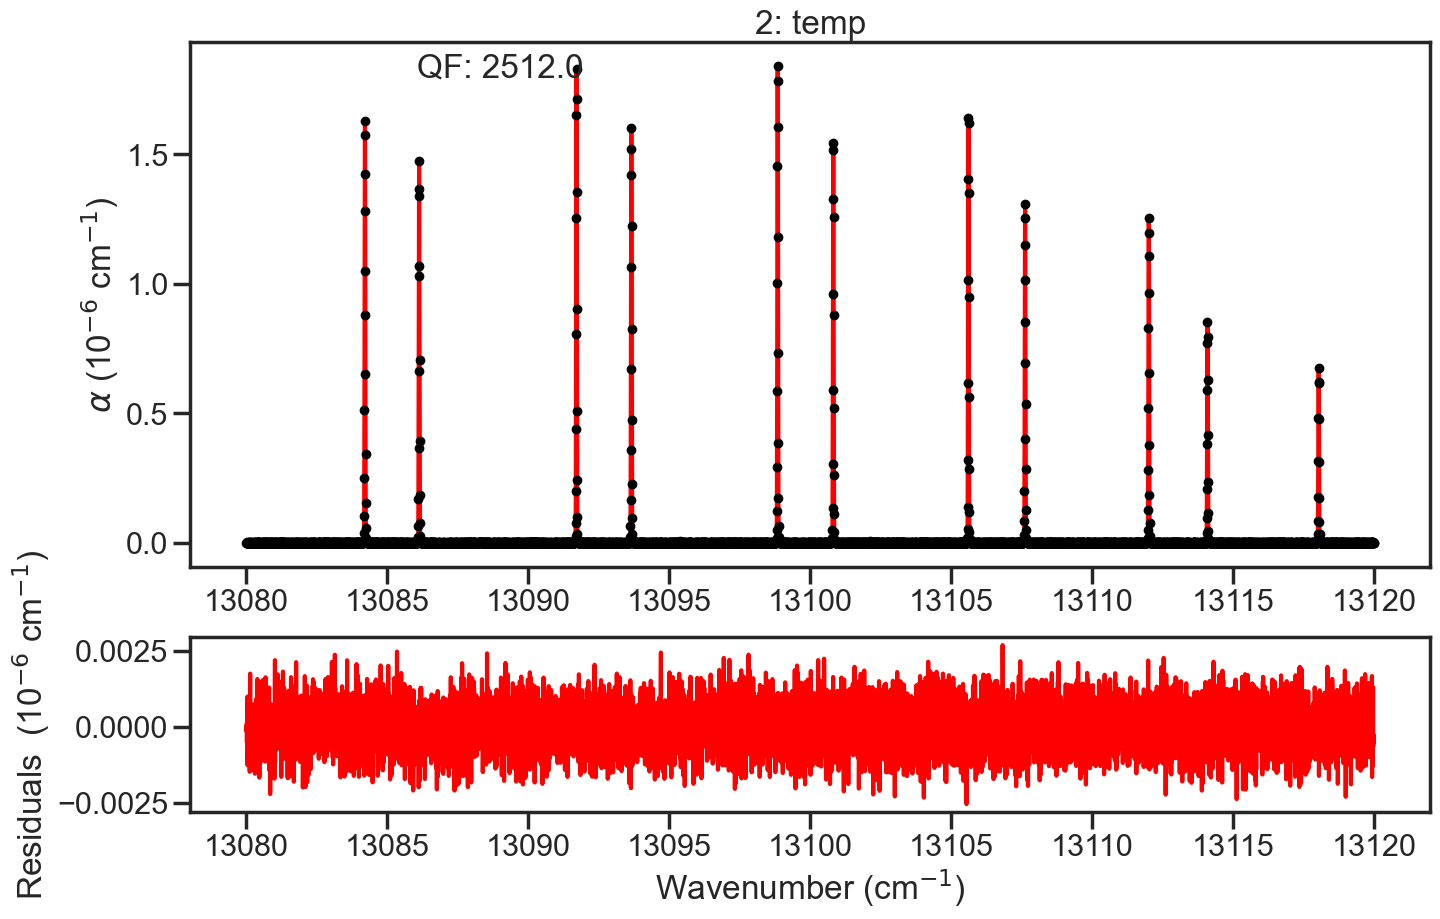

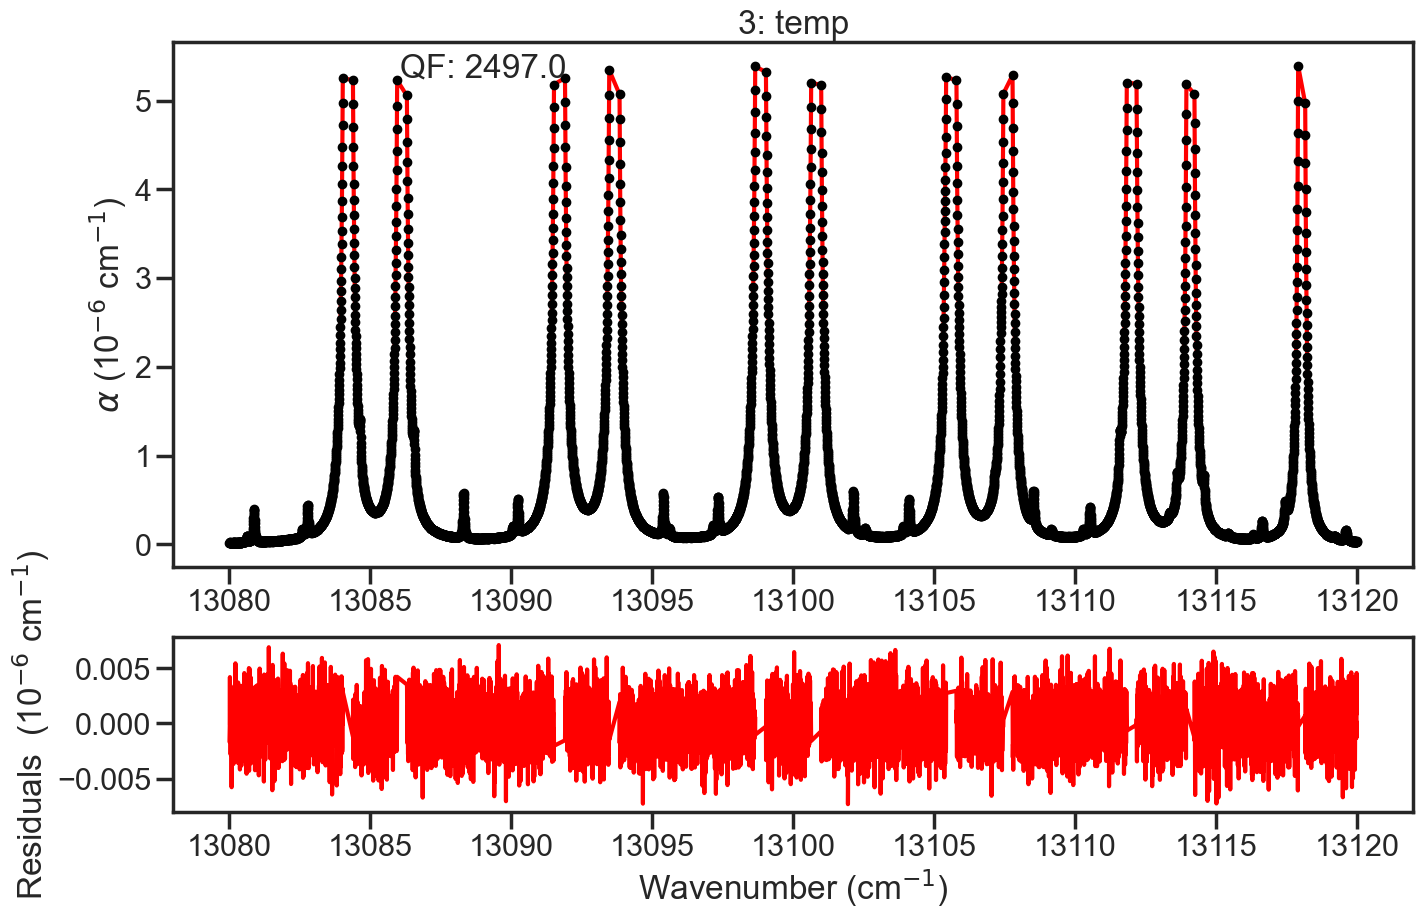

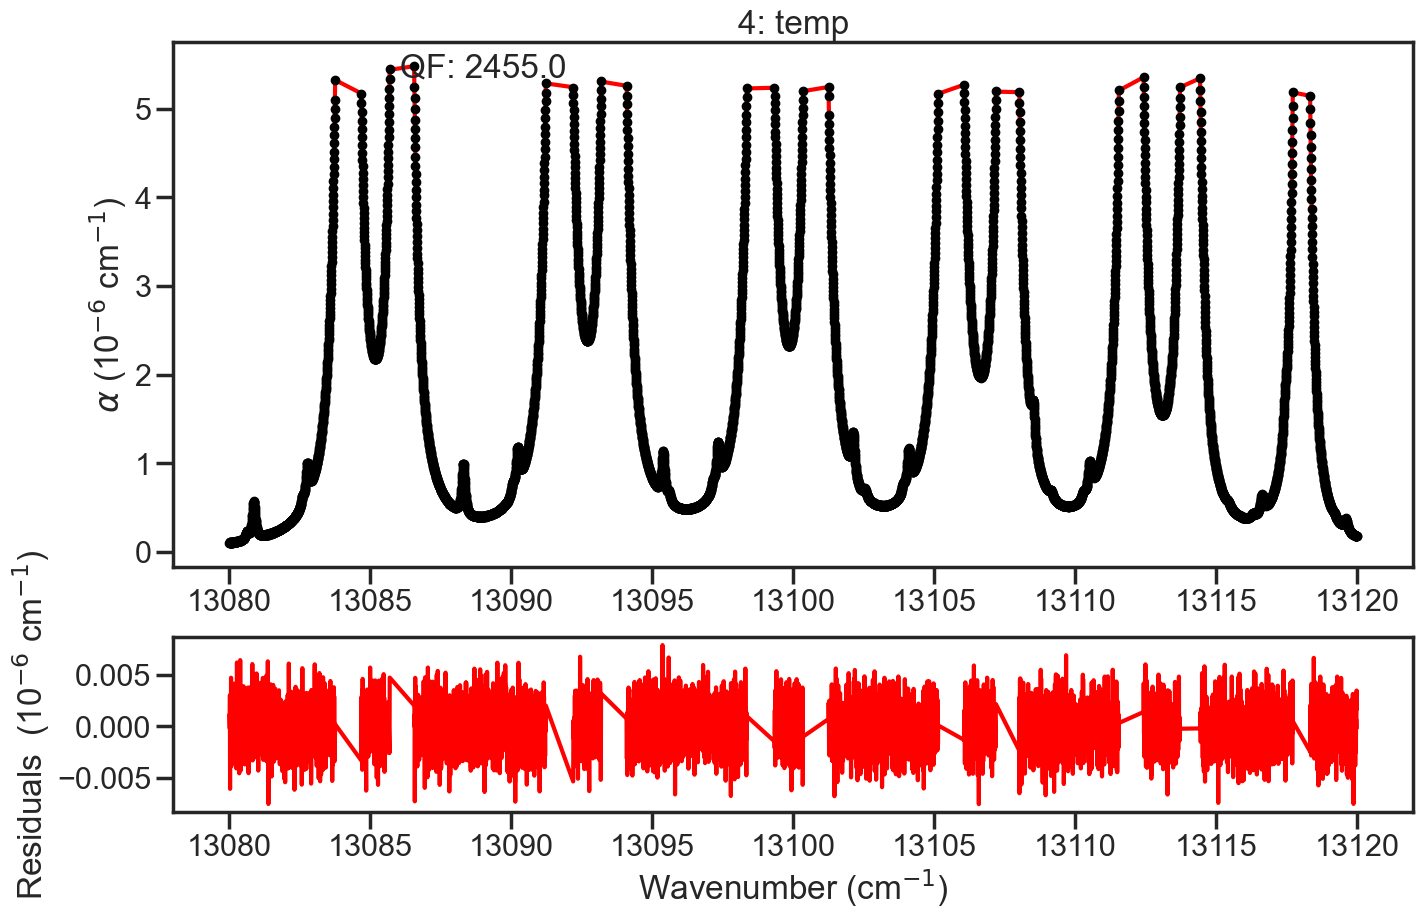

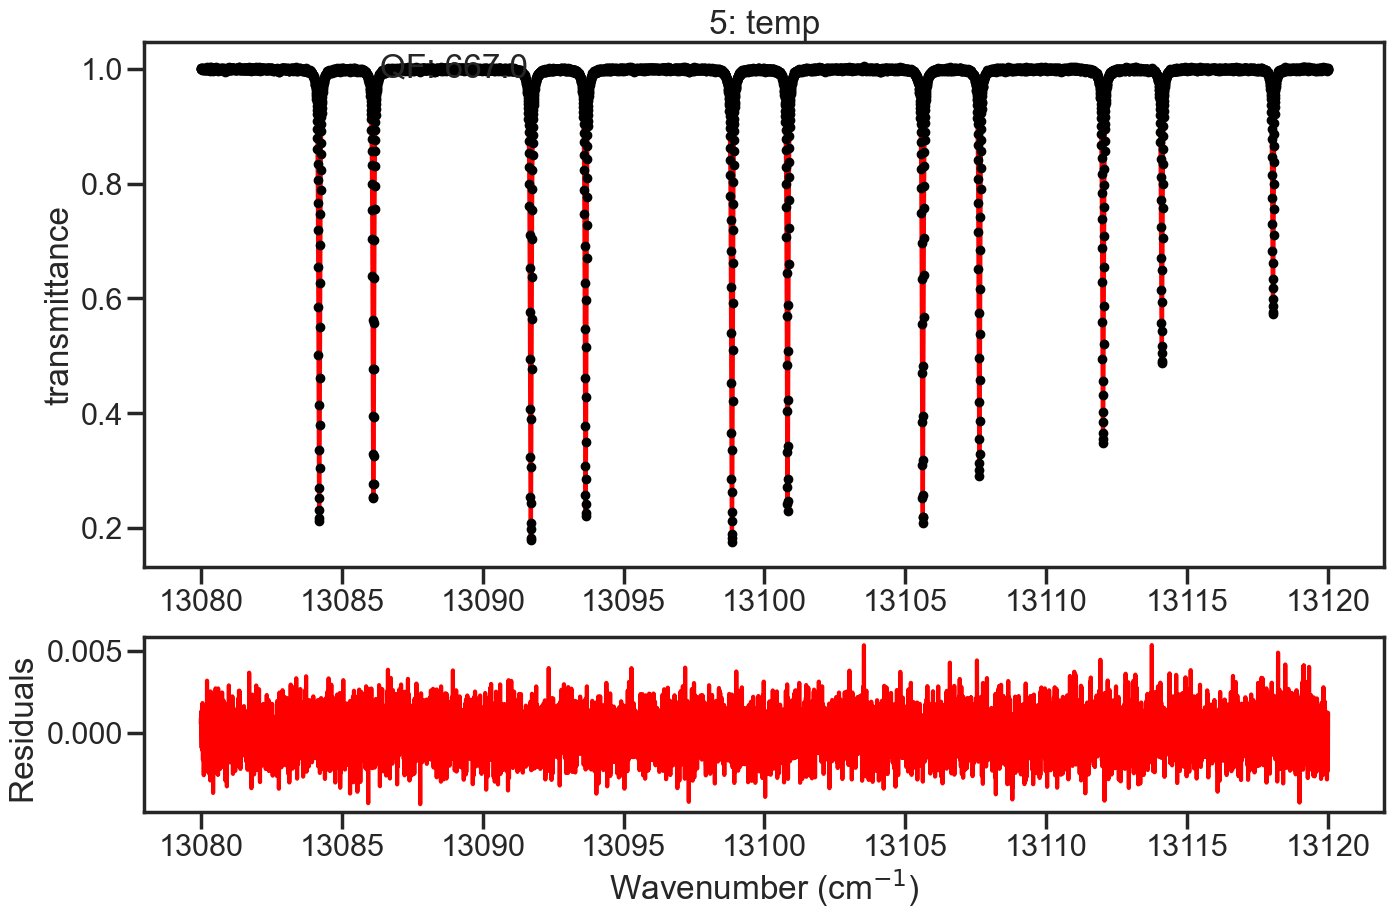

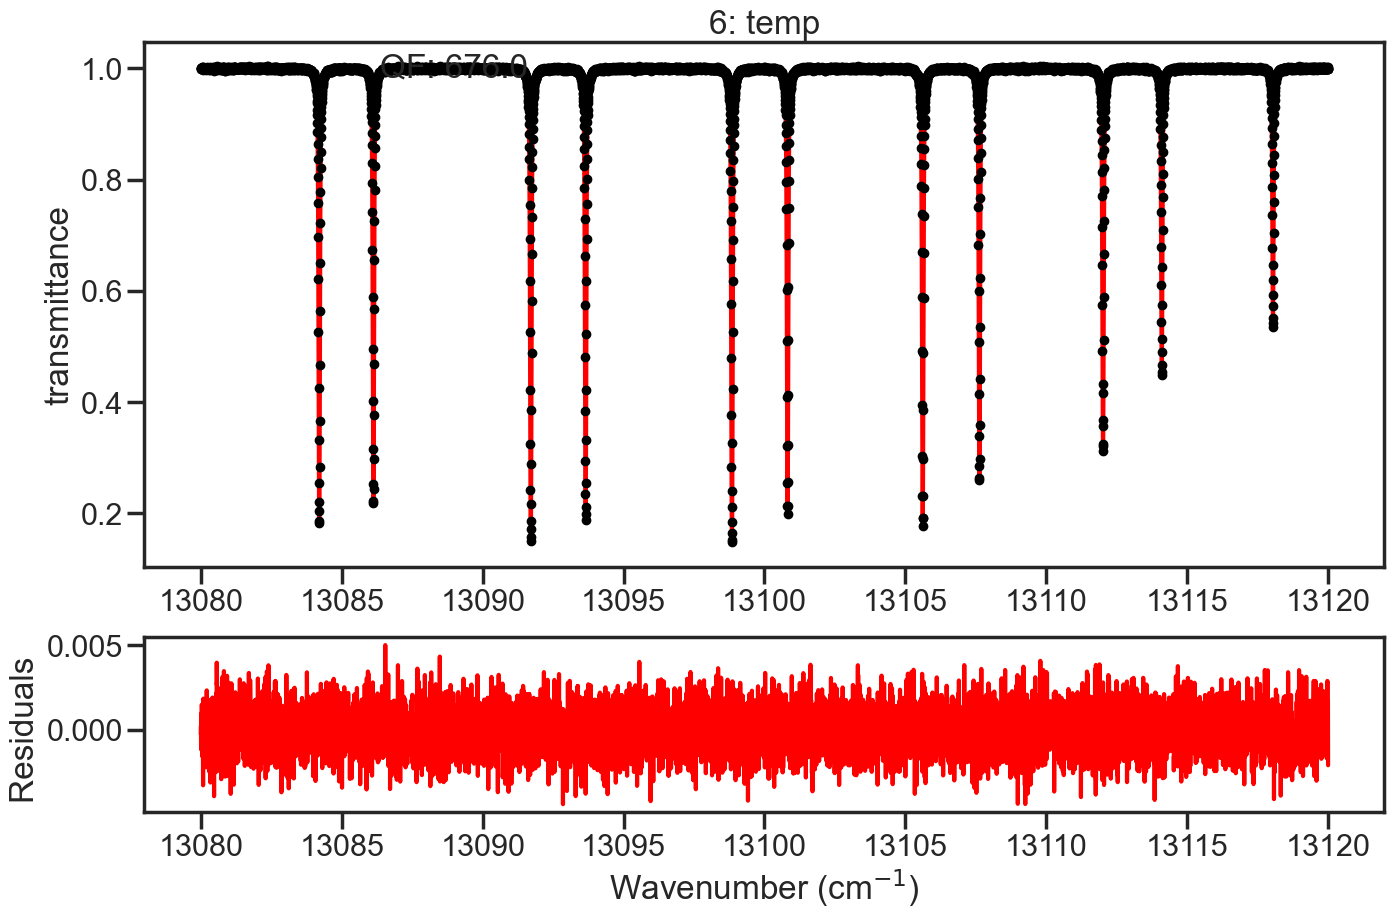

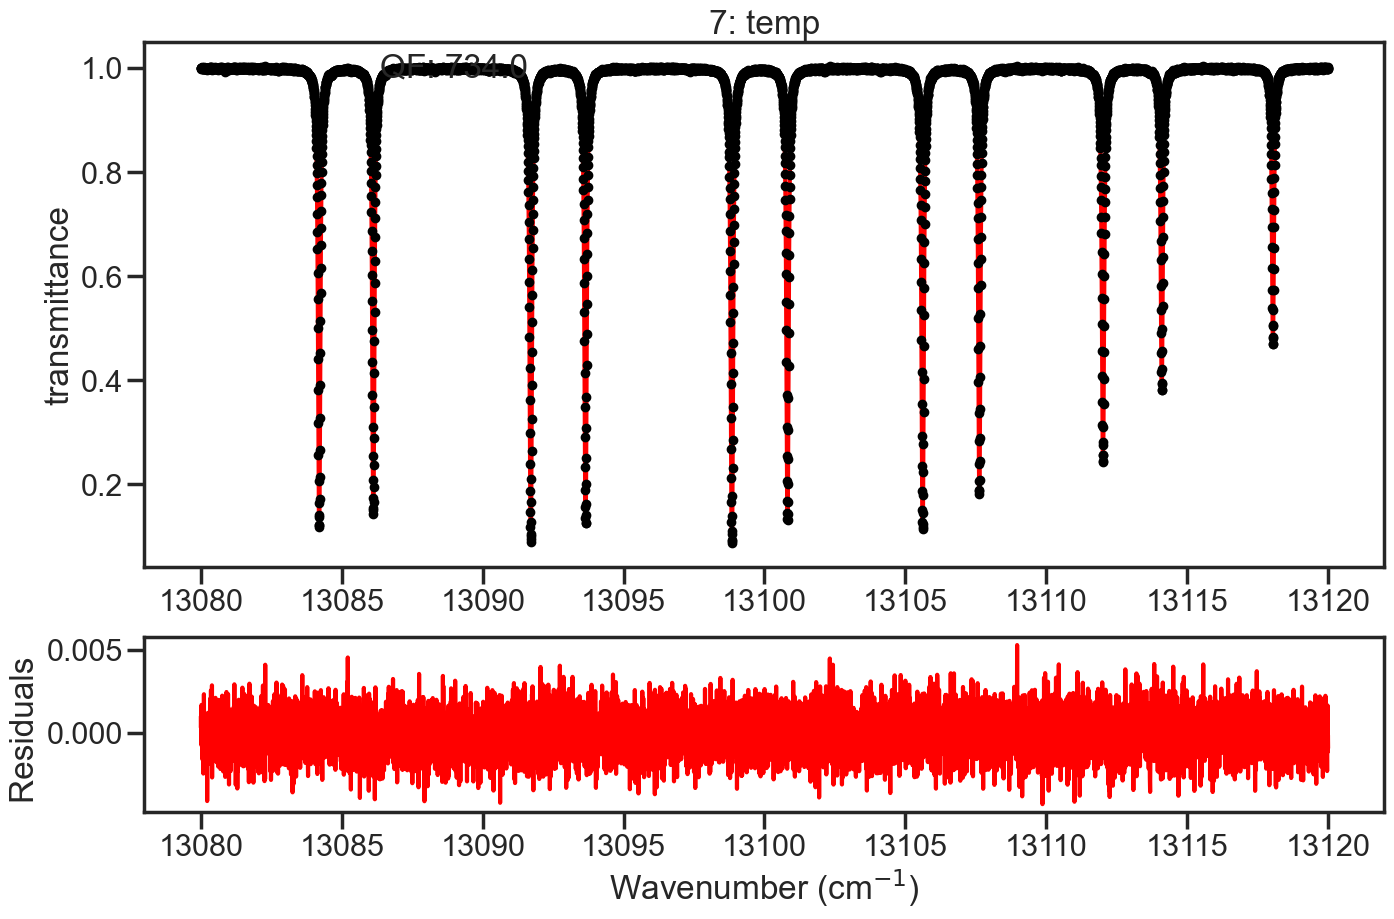

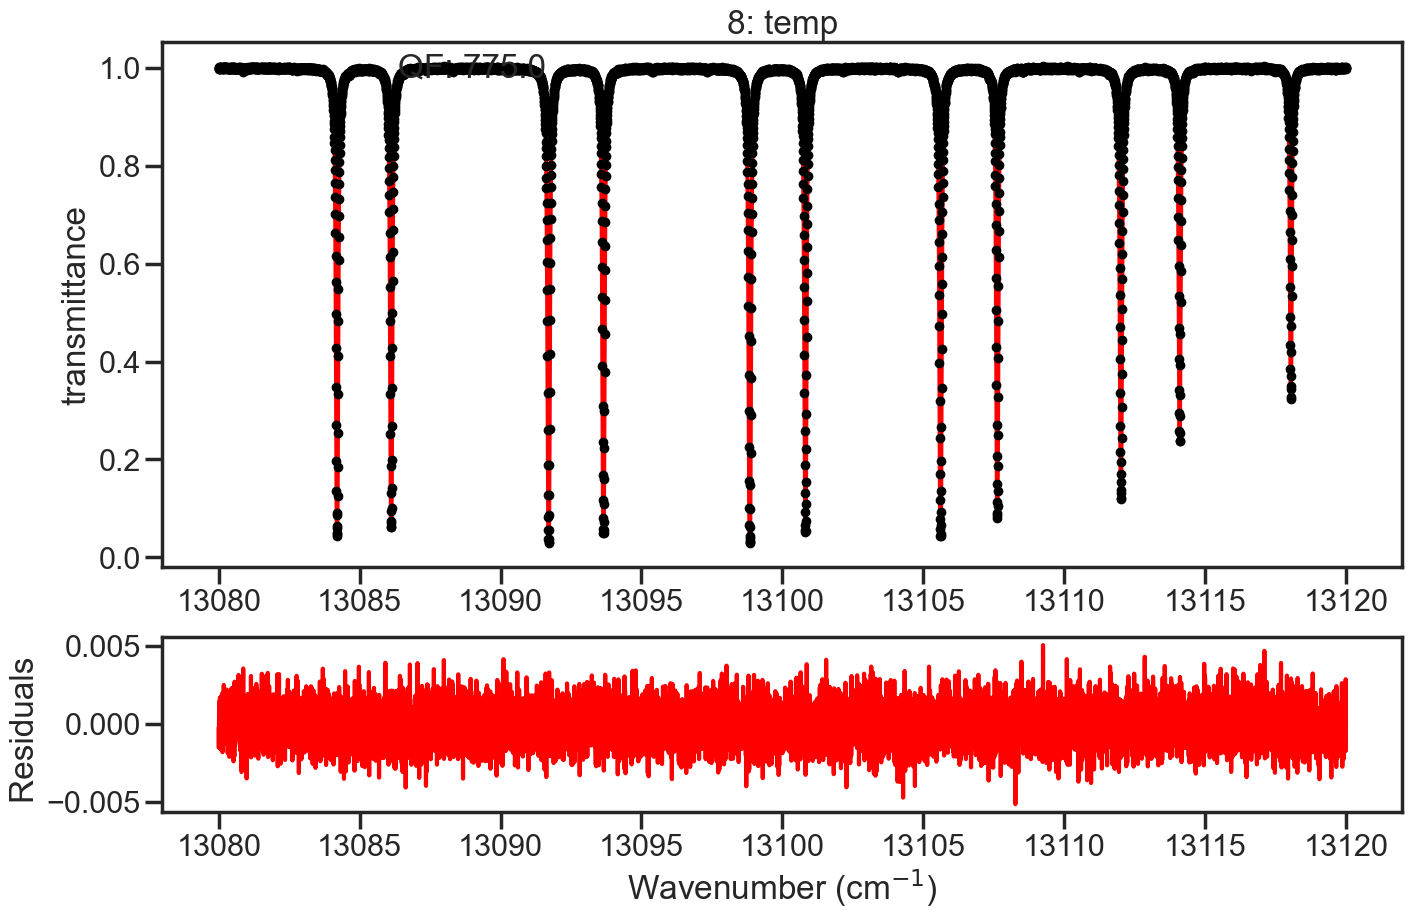

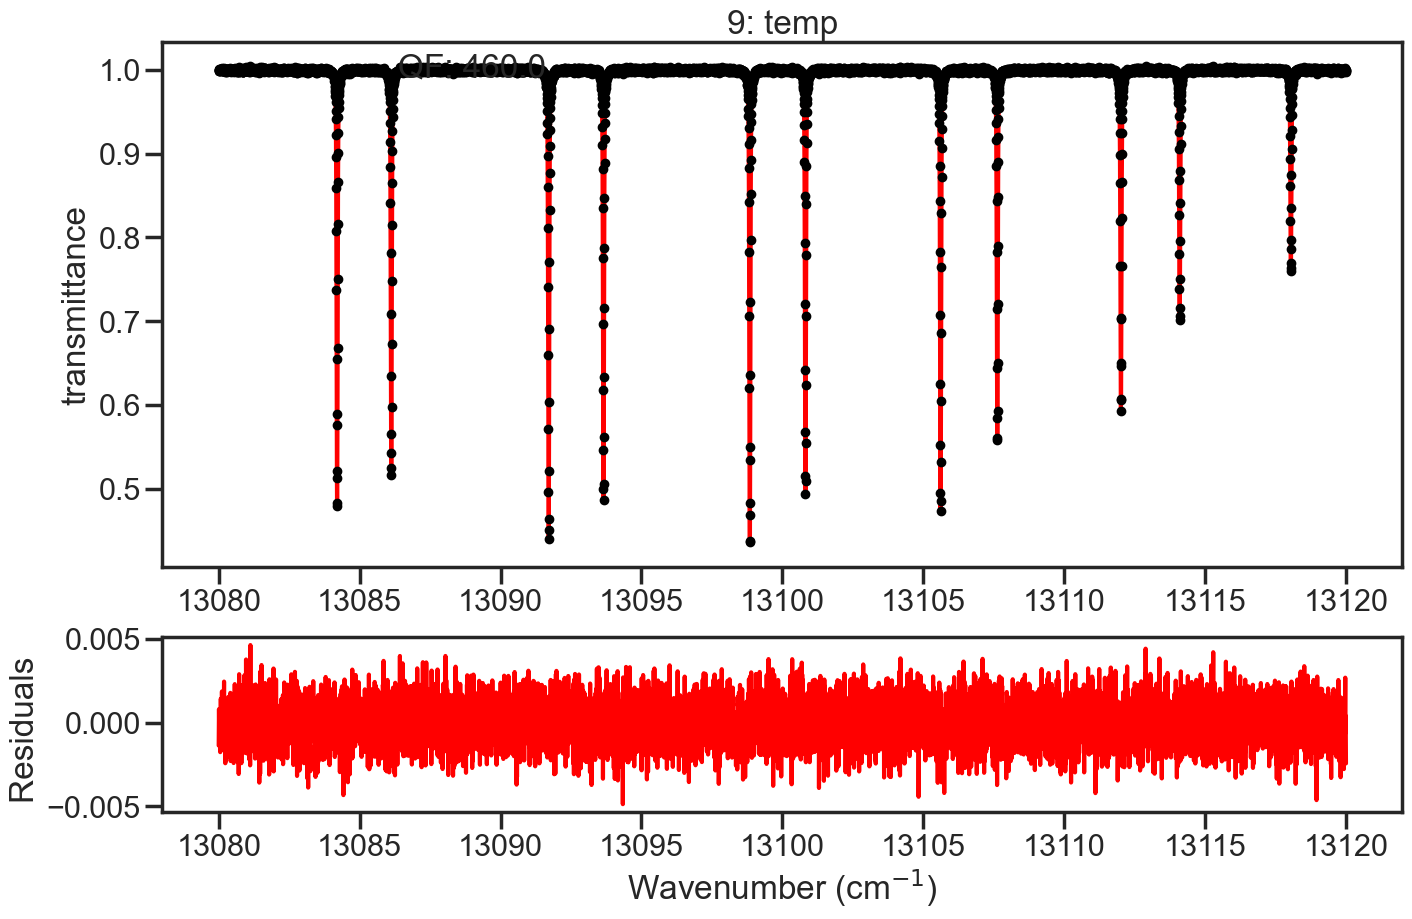

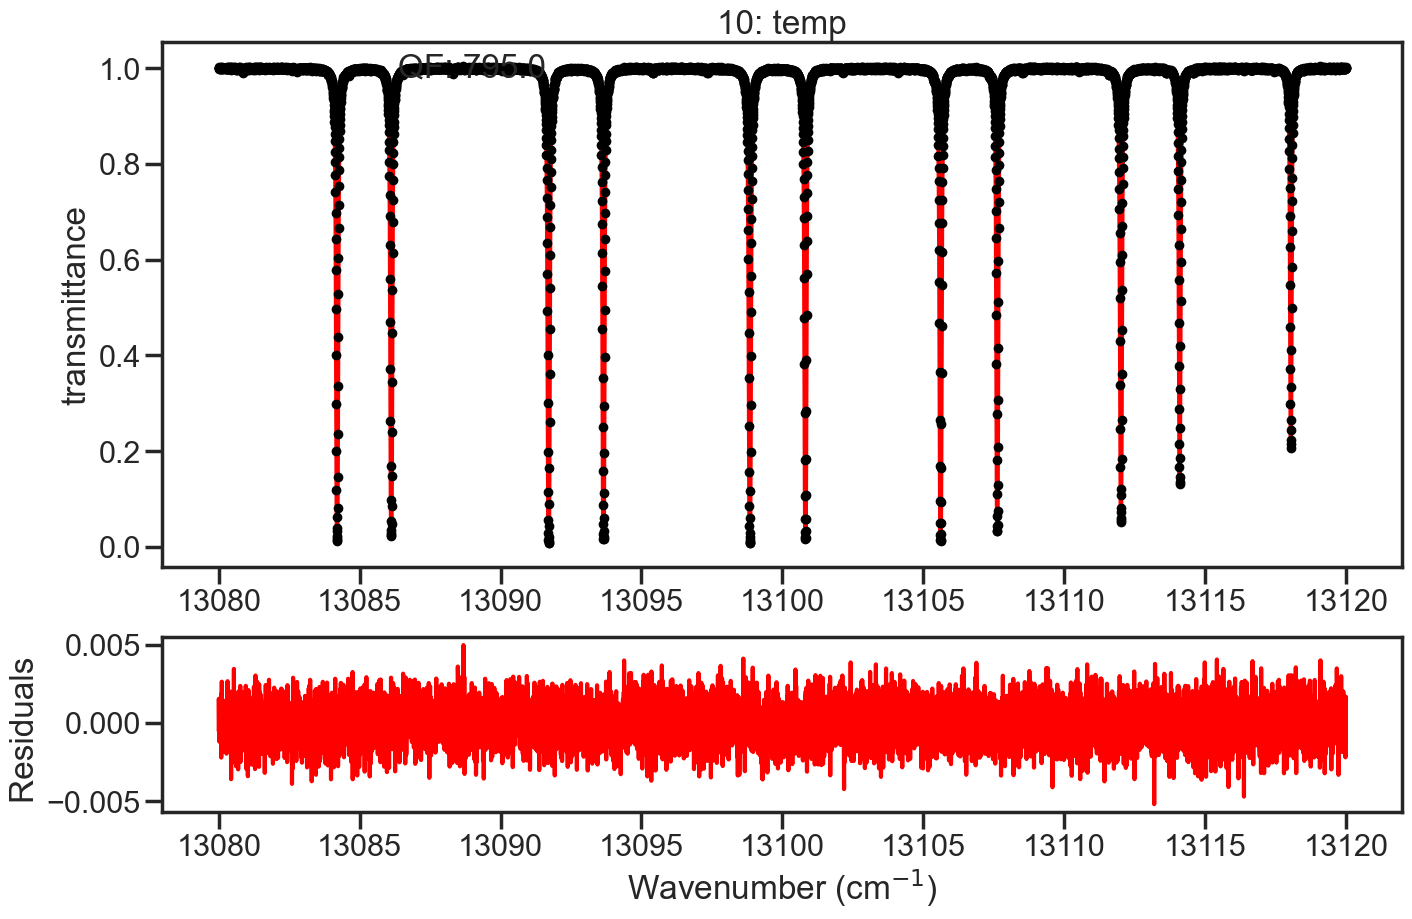

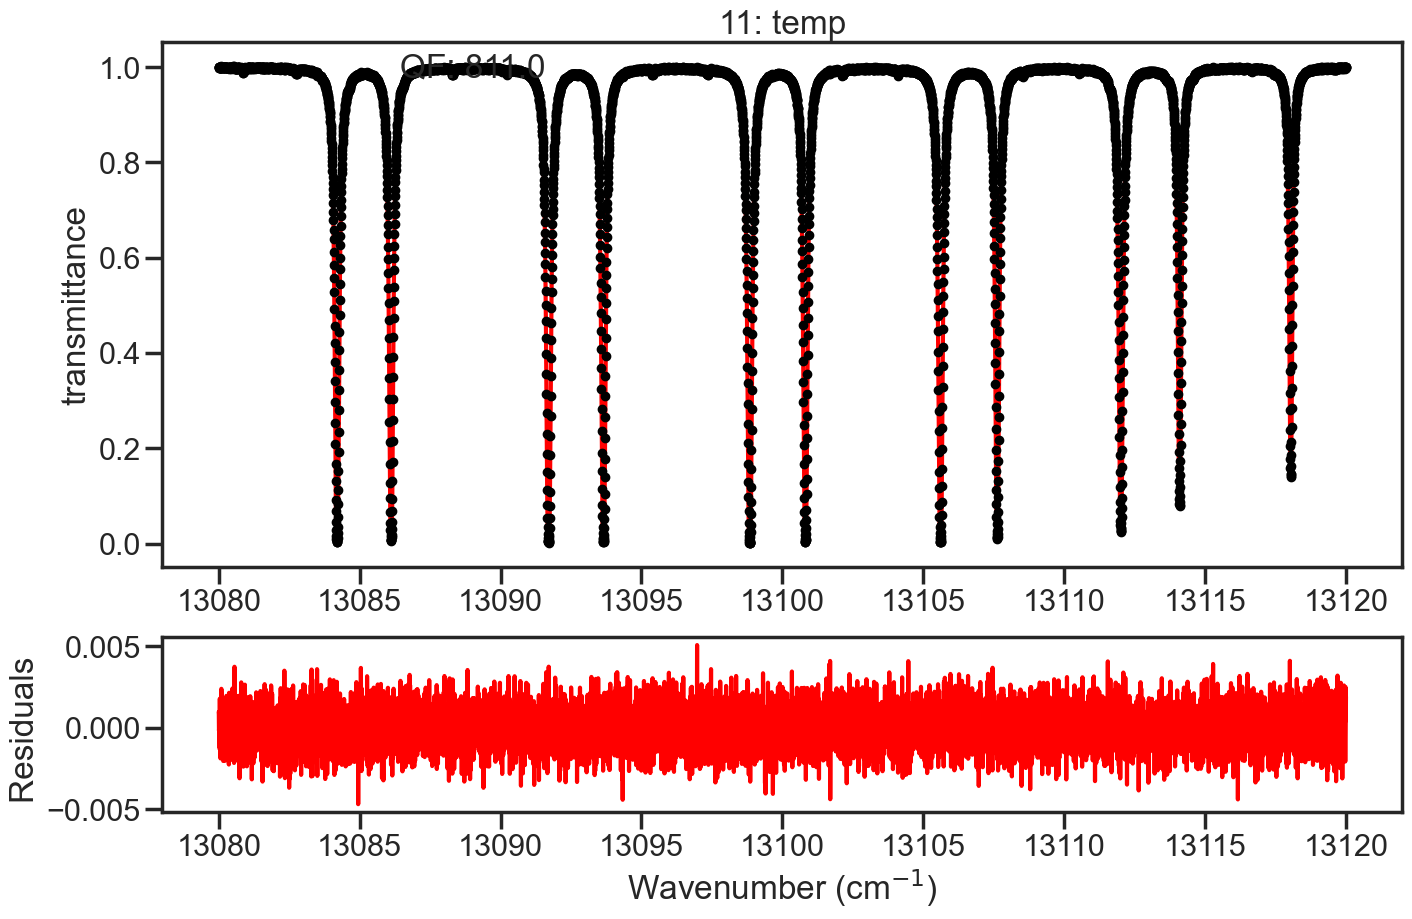

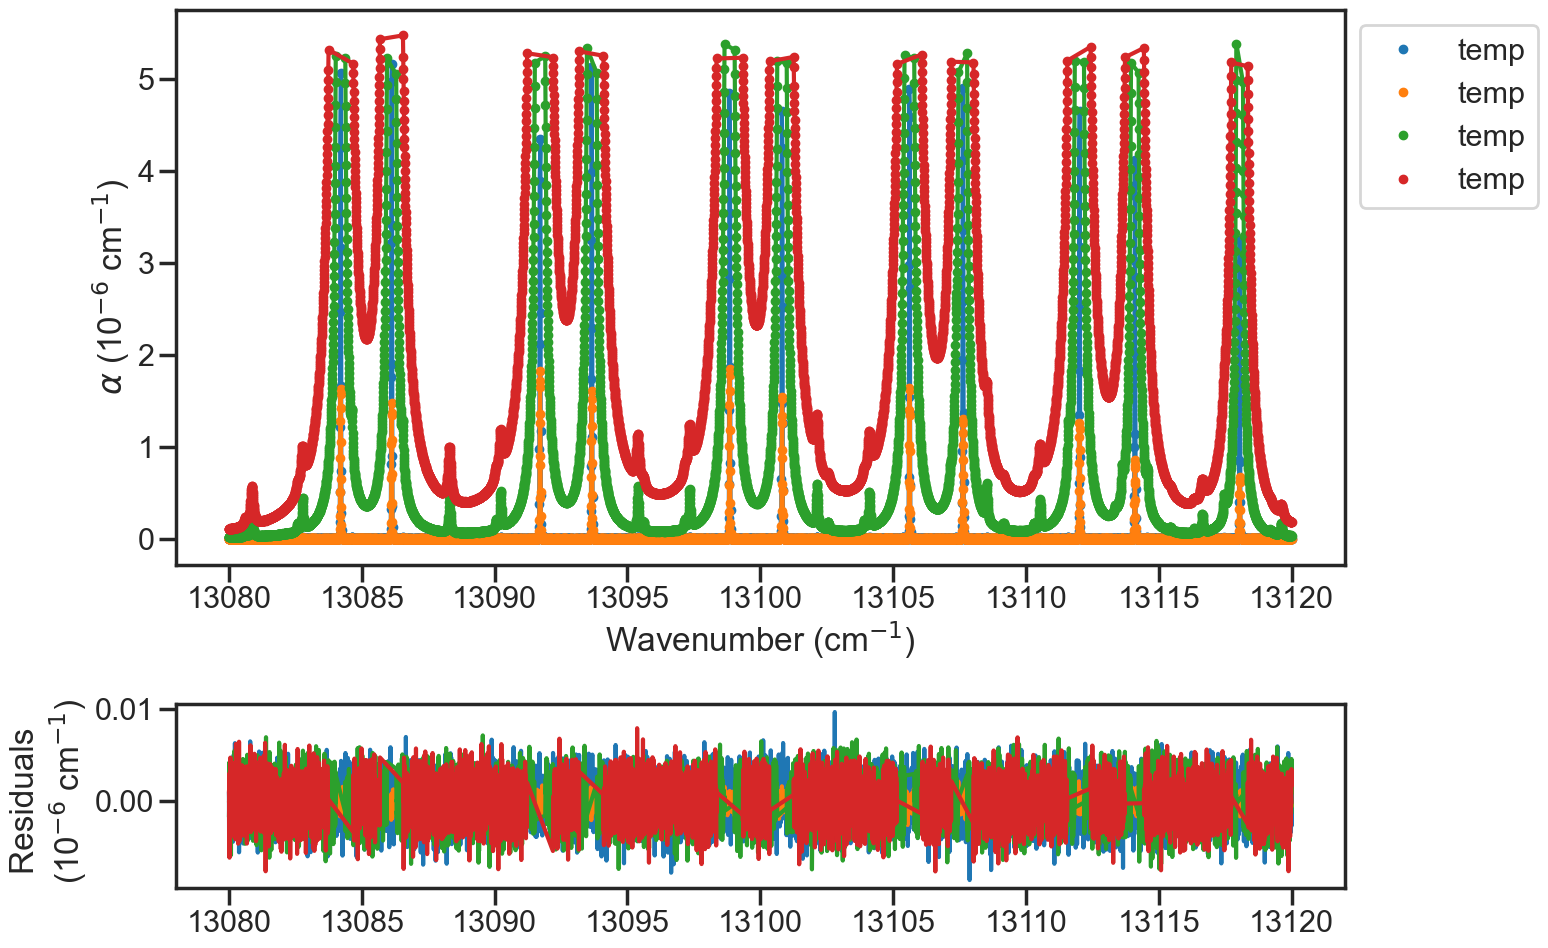

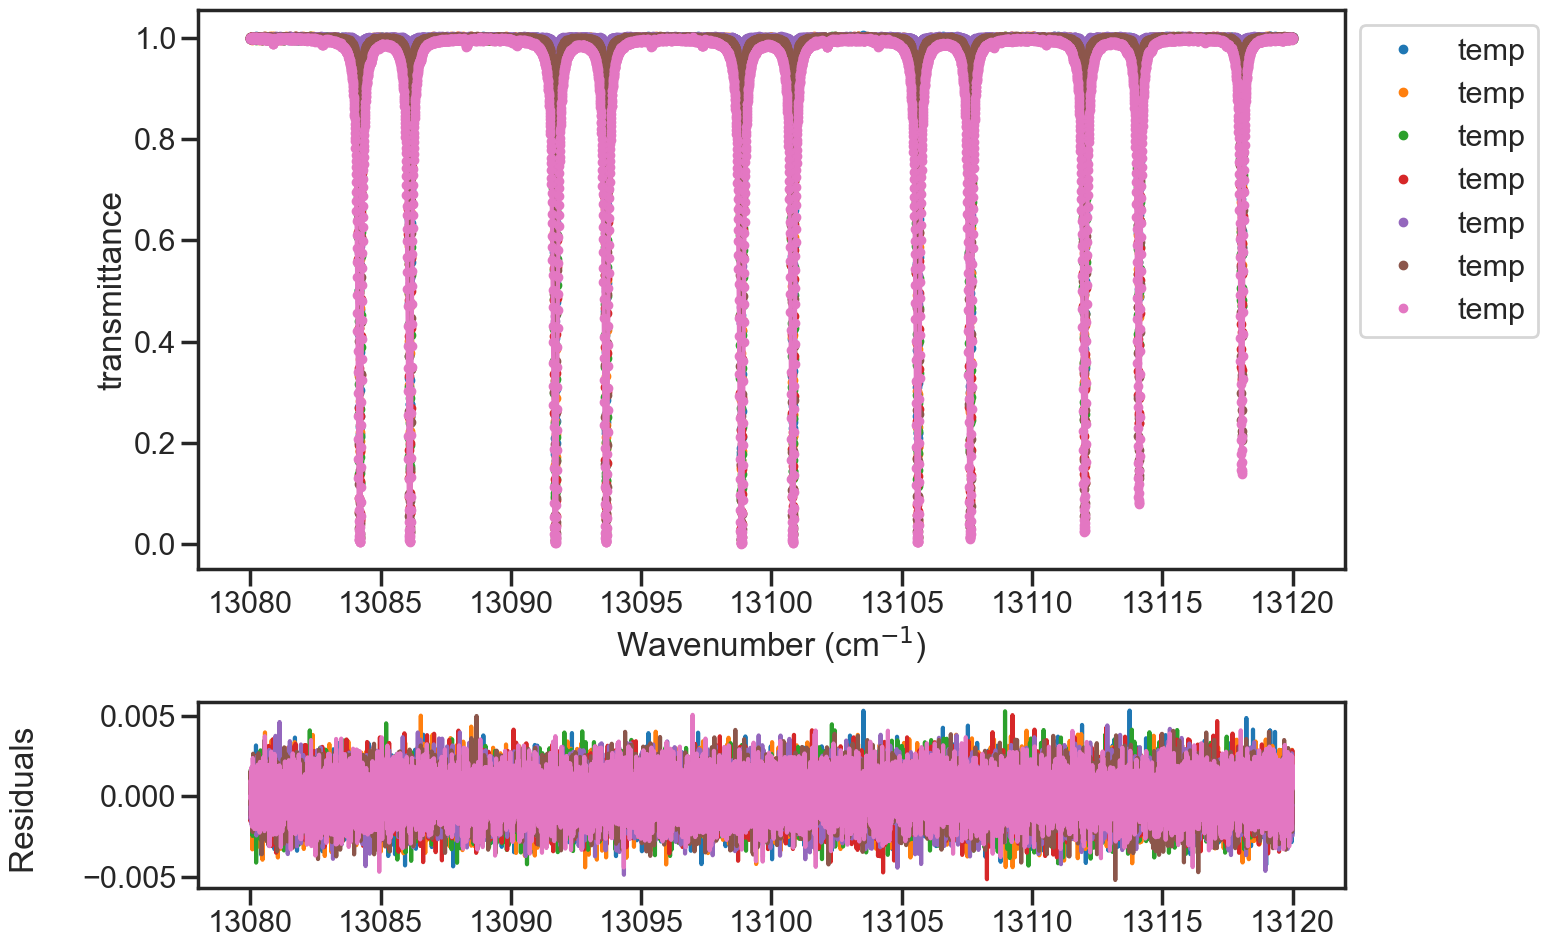

In [5]:
fit_data = MATS.Fit_DataSet(SPECTRA,'Baseline_LineList', 'Parameter_LineList', minimum_parameter_fit_intensity = Fit_Intensity)
params = fit_data.generate_params()





result = fit_data.fit_data(params, wing_wavenumbers = 25, wing_method = 'wing_wavenumbers')
print (result.params.pretty_print())

fit_data.residual_analysis(result, indv_resid_plot=True)
fit_data.update_params(result)
SPECTRA.generate_summary_file(save_file = True)
SPECTRA.plot_model_residuals()